# Hydraulic Predictive Maintenance — Stage 3: Model Development & Experiment Tracking

**Client:** Bosch Rexroth AG · **Stage:** 3 of 7 · **Notebook:** `03_Model_Development_and_Experiment_Tracking.ipynb`
**Builds on:** Stage 2 dataset, feature list and folds (`v0.2.0-stage2`) · **Code:** `src/pdm/models`, `src/pdm/train.py`

---

## Purpose

Stage 2 delivered a model-ready table: about 10,700 eligible machine-hours, 171 screened features, rebuilt targets and fixed leave-one-machine-out (LOMO) folds. Stage 3 answers three questions on machines the model has **never seen**:

1. **Which failure mode is developing?** (classification)
2. **How many hours until failure?** (RUL regression, capped at 14 days)
3. **Will this machine fail in the next 7 days, and how early can we say so without flooding the site with false alarms?** (early warning)

Every run is tracked in **MLflow** with its parameters, metrics, feature list, git commit, config hash and dataset fingerprint. The selected model per task is explained with **SHAP** and registered in the **MLflow Model Registry**, ready for Stage 4.

## How the Stage 2 plan is implemented

| Stage 2 plan item | Implementation | Module |
|---|---|---|
| 1. MLflow tracking | one parent run per training call, one nested run per task × model; tags: git commit, config hash, dataset hash | `models/tracking.py` |
| 2. Baselines first | EDA §8.3 rule detector (alarm + mode from the rule that fired), logistic regression; constant and ridge for RUL | `models/baselines.py`, `models/estimators.py` |
| 3. Failure-mode classification | LightGBM and XGBoost, balanced class weights; macro-F1 and confusion matrix per LOMO fold | `models/cv.py` |
| 4. RUL regression | LightGBM and XGBoost on the capped RUL (censored rows excluded); MAE, RMSE, asymmetric NASA score | `models/cv.py`, `models/metrics.py` |
| 5. Early warning | calibrated P(fail within 7 d); calibration and alarm threshold chosen by an **inner** LOMO; lead time at a fixed false-alarm rate (false alarm = alarm on a healthy hour) | `models/cv.py` |
| 6. Sequence model (optional) | not built in this stage; see §9 | — |
| 7. Explainability and registry | SHAP (global and per alert); pyfunc models registered, `@champion` alias only if every baseline is beaten | `models/explain.py`, `models/registry.py` |

## Contents
1. Environment and project setup
2. Evaluation protocol
3. Stage 2 inputs
4. Training run (all tasks, tracked in MLflow)
5. Experiment tracking
6. Failure-mode classification
7. RUL regression
8. Early warning
9. Sequence model: decision
10. Explainability (SHAP)
11. Model Registry
12. Summary and plan for Stage 4

## 1. Environment and project setup

**Google Colab:** the project folder `bosch_rexroth_pdm/` on Google Drive, with the three CSVs in `data/raw/`, as in notebook 02. The cell mounts Drive, installs the dependencies (now including LightGBM, XGBoost, MLflow and SHAP) and the `pdm` package.
Locally, the cell just locates the project root. The MLflow store is `mlflow.db` + `mlartifacts/` in the project root (both git-ignored, like the data).

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/bosch_rexroth_pdm")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_DIR / "requirements.txt")], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(PROJECT_DIR)], check=True)
else:
    PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / "src"))
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
print("Project root:", PROJECT_DIR)

Project root: /home/claude/hydraulic-predictive-maintenance


In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

import mlflow
import pdm
from pdm.config import load_config
from pdm.models.data import load_model_data, classification_rows, rul_rows, warning_rows
from pdm.models.tracking import tracking_uri
from pdm.train import run as train_run, PRIMARY, CANDIDATES

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
print("pdm", pdm.__version__, "| mlflow", mlflow.__version__, "| pandas", pd.__version__)
FIG_DIR = Path("reports/figures")
show = lambda name, width=900: display(Image(filename=str(FIG_DIR / f"stage3_{name}.png"), width=width))

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pdm 0.3.0 | mlflow 3.16.1 | pandas 3.0.2


### 1.1 Quality gate: run the unit tests first

The suite now has 43 tests. The 16 new Stage 3 tests check, among others, that **no model is ever trained on the machine it scores** (a spy on every early-warning fit), that the alarm threshold is the lowest one meeting the false-alarm target, that the NASA score punishes late predictions more than early ones, that an alarm during early degradation is not counted as a false alarm, and that a model registered in MLflow predicts exactly what it predicted before logging.

In [3]:
r = subprocess.run([sys.executable, "-m", "pytest", "--color=no", "-p", "no:cacheprovider", "-W", "ignore"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])
assert r.returncode == 0, "Unit tests failed: fix before training"


43 passed in 11.67s


## 2. Evaluation protocol

**Leave-one-machine-out, out-of-fold.** Fold *k* holds out one machine completely; the model that scores a machine never saw any hour of it. All metrics below are pooled over the ten held-out machines unless stated otherwise.

**Rows per task** (all restricted to Stage 2 `eligible` rows: no repair downtime, no baseline period, no standby):

| Task | Target | Rows used | Primary metric (selection and gate) |
|---|---|---|---|
| Failure mode | `failure_mode_label` (healthy + 4 modes) | eligible | **macro-F1 on the folds whose mode was seen in training** |
| RUL | `rul_hours` (cap 336 h) | eligible, RUL known (censored rows excluded) | **MAE in the last 14 days before a failure** (true RUL < cap) |
| Early warning | `fail_within_h` (≤ 168 h) | eligible, target known | **mean lead time per failure event** (a missed event counts 0 h) at a fixed false-alarm rate |

**Why these headline metrics.**
* *Macro-F1* weights the rare modes (contamination 240 h, cylinder drift 192 h) as much as healthy hours. The HPU_06 fold (the only cylinder-drift machine) cannot be classified by name, so its detection rate is reported **separately**, not averaged away.
* *RUL on the critical window:* about two thirds of known-RUL rows sit at the 336 h cap. An error averaged over all rows mostly measures how well the model says "not soon"; the last 14 days are where maintenance is planned.
* *NASA score (PHM08):* with d = (predicted − true) / 24 h, a late prediction costs exp(d/10) − 1 and an early one exp(−d/13) − 1. Promising more life than the machine has is the expensive error.
* *What counts as a false alarm:* an alarm while the machine is **healthy**, i.e. no failure within 7 days *and* outside every labelled degradation window. Pump-wear and valve-leakage windows are 10–14 days long, so their first days are degradation hours with a 7-day target of 0. An alarm there is a correct *early* detection, not a false alarm. Those "early" hours are also left out when the early-warning model is fitted and calibrated: labelling them "will not fail" would teach the model to ignore a genuine degradation signal.
* *Lead time at a fixed false-alarm rate:* a longer warning is worthless if bought with more false alarms. The operating point is `target_false_alarm_rate = 0.2 %` of healthy hours in alarm (≈ one alarm-hour per three weeks per machine), with 3 consecutive hours needed to raise an alarm. If the EDA rules achieve a **lower** false-alarm rate, the models are re-evaluated at the rules' rate so the comparison is always like for like.

**Early warning without leakage.** Calibration (isotonic) and the alarm threshold are fitted on an **inner** LOMO over the nine training machines of each outer fold; the held-out machine influences neither. The deployed model uses the calibrator and threshold fitted on the outer out-of-fold scores of all ten machines.

**No hyperparameter tuning.** With nine failure events, tuning on the LOMO score would fit the evaluation itself. The gradient-boosting settings are fixed, conservative defaults (`configs/config.yaml → modelling.models`), and the comparison is between model *families*, not tuned variants.

**Gate.** A model gets the registry alias `@champion` only if it beats **every** baseline of its task on the primary metric (and, for early warning, stays within the false-alarm budget).

## 3. Stage 2 inputs

Stage 3 reads exactly what Stage 2 persisted. If the processed files are missing (for example on a fresh Colab runtime), the Stage 2 pipeline is run first.

In [4]:
cfg = load_config("configs/config.yaml")
if not (cfg["paths"]["processed_dir"] / "dataset.parquet").exists():
    from pdm.pipeline import run as pipeline_run
    pipeline_run(cfg, verbose=False)
data = load_model_data(cfg)
ds = data.ds
print(f"Dataset {data.dataset_hash}: {len(ds):,} machine-hours, {len(data.features)} features")
counts = pd.DataFrame({"classification": classification_rows(ds).sum(), "RUL (known)": rul_rows(ds).sum(),
                       "early warning": warning_rows(ds).sum()}, index=["rows"])
display(counts)
display(ds[classification_rows(ds)].groupby("failure_mode_label").agg(hours=("timestamp", "size"), machines=("machine_id", "nunique")).T)
display(data.events)

Dataset 0f087751a4eb: 14,400 machine-hours, 171 features


,classification,RUL (known),early warning
rows,10688,8080,9208


failure_mode_label,contamination,cylinder_drift,healthy,pump_wear,valve_leakage
hours,240,192,8576,960,720
machines,2,1,10,3,3


,event_id,machine_id,failure_timestamp,failure_mode,degradation_start_timestamp
0,F_009,HPU_09,2024-01-26,contamination,2024-01-21
1,F_005,HPU_05,2024-01-31,valve_leakage,2024-01-21
2,F_003,HPU_03,2024-02-08,contamination,2024-02-03
3,F_008,HPU_08,2024-02-12,pump_wear,2024-01-29
4,F_001,HPU_01,2024-02-15,pump_wear,2024-02-01
5,F_006,HPU_06,2024-02-18,cylinder_drift,2024-02-10
6,F_002,HPU_02,2024-02-22,valve_leakage,2024-02-12
7,F_007,HPU_07,2024-02-25,valve_leakage,2024-02-15
8,F_004,HPU_04,2024-02-28,pump_wear,2024-02-16


## 4. Training run (all tasks, tracked in MLflow)

`pdm.train.run` is the same function as the command line `python -m pdm.train`. It evaluates every baseline and model for each task, logs each as a nested MLflow run, selects and gates the best model, fits it on all ten machines, explains it and registers it. The notebook then reads the results back, so the notebook and the CLI cannot diverge.

Runtime is about 8 minutes on a 2-core machine (the early-warning task fits 100 models per candidate because of the nested protocol); allow longer on a free Colab runtime.

In [5]:
report = train_run(cfg, data_label="real")
print("MLflow parent run:", report["mlflow_parent_run_id"], "| runtime", report["runtime_s"], "s")
pd.DataFrame({t: e["gate"] for t, e in report["tasks"].items()}).T

2026/09/28 12:56:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/28 12:56:51 INFO mlflow.store.db.utils: Updating database tables


[   2.8s] failure_mode   rules     macro_f1_seen=0.623, macro_f1_all=0.655


[  11.8s] failure_mode   logreg    macro_f1_seen=0.944, macro_f1_all=0.734


[  50.3s] failure_mode   lightgbm  macro_f1_seen=0.988, macro_f1_all=0.745


...

Successfully registered model 'hpu-early-warning'.
Created version '1' of model 'hpu-early-warning'.


[ 596.3s] early_warning: final lightgbm logged as hpu-early-warning v1 @champion


[ 596.3s] done


MLflow parent run: 3bf75f1ca15f42d48d9d240383965748 | runtime 596.3 s


,selected,primary_metric,value,higher_is_better,beats_baselines,within_false_alarm_budget,passes_gate
failure_mode,lightgbm,macro_f1_seen,0.988492,True,"{'rules': True, 'logreg': True}",True,True
rul,xgboost,mae_critical,39.886462,False,"{'constant': True, 'ridge': True}",True,True
early_warning,lightgbm,lead_time_mean_h,220.888889,True,"{'rules': True, 'logreg': True}",True,True


## 5. Experiment tracking

Every evaluation above is an MLflow run. The table is queried from the tracking store, not from the in-memory report: this is what a reviewer sees in `mlflow ui --backend-store-uri sqlite:///mlflow.db` (or `make mlflow-ui`). Per-fold metrics are stored as step series (`fold_<metric>`, step = fold), and each run carries the git commit, config hash and dataset fingerprint, so any number can be traced to the exact code, settings and data that produced it.

In [6]:
mlflow.set_tracking_uri(tracking_uri(cfg))
runs = mlflow.search_runs(experiment_names=[cfg["modelling"]["tracking"]["experiment"]],
                          filter_string=f"tags.mlflow.parentRunId = '{report['mlflow_parent_run_id']}'")
keep = ["tags.mlflow.runName", "tags.git_commit", "tags.config_hash", "tags.dataset_hash",
        "metrics.macro_f1_seen", "metrics.mae_critical", "metrics.lead_time_mean_h", "metrics.false_alarm_rate"]
view = runs[[c for c in keep if c in runs.columns]].rename(columns=lambda c: c.split(".", 1)[1])
view["git_commit"] = view["git_commit"].str[:8]
view.sort_values("mlflow.runName" if "mlflow.runName" in view else view.columns[0]).round(4)

,mlflow.runName,git_commit,config_hash,dataset_hash,macro_f1_seen,mae_critical,lead_time_mean_h,false_alarm_rate
2,early_warning/lightgbm,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,219.7778,0.0000
4,early_warning/lightgbm,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,220.8889,0.0000
5,early_warning/logreg,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,205.6667,0.0101
6,early_warning/rules,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,195.3333,0.0000
1,early_warning/xgboost,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,213.6667,0.0026
3,early_warning/xgboost,e5a68af0,ceca379c192d,0f087751a4eb,NaN,NaN,217.1111,0.0043
14,failure_mode/lightgbm,e5a68af0,ceca379c192d,0f087751a4eb,0.9885,NaN,NaN,NaN
15,failure_mode/logreg,e5a68af0,ceca379c192d,0f087751a4eb,0.9441,NaN,NaN,NaN
16,failure_mode/rules,e5a68af0,ceca379c192d,0f087751a4eb,0.6229,NaN,NaN,NaN
13,failure_mode/xgboost,e5a68af0,ceca379c192d,0f087751a4eb,0.9884,NaN,NaN,NaN


## 6. Failure-mode classification

Pooled out-of-fold results. *macro-F1 (seen folds)* excludes the HPU_06 fold, whose mode is absent from training; *HPU_06 detection* is the share of HPU_06's degradation hours flagged as **any** failure mode there. *Events correct* reads the model the way an engineer would: over each degradation window, which mode did the model point to most often?

In [7]:
def table(task, cols):
    rows = {n: {c: m["summary"].get(c) for c in cols} for n, m in report["tasks"][task]["models"].items()}
    return pd.DataFrame(rows).T

t = table("failure_mode", ["macro_f1_seen", "macro_f1_all", "accuracy_seen", "detection_recall",
                           "healthy_false_positive_rate", "unseen_fold5_detection_recall", "events_mode_correct"])
t.round(3)

,macro_f1_seen,macro_f1_all,accuracy_seen,detection_recall,healthy_false_positive_rate,unseen_fold5_detection_recall,events_mode_correct
rules,0.623,0.655,0.900,0.837,0.000,0.646,6.0
logreg,0.944,0.734,0.983,0.958,0.004,0.995,8.0
lightgbm,0.988,0.745,0.993,0.962,0.000,0.906,8.0
xgboost,0.988,0.767,0.994,0.964,0.000,0.917,8.0


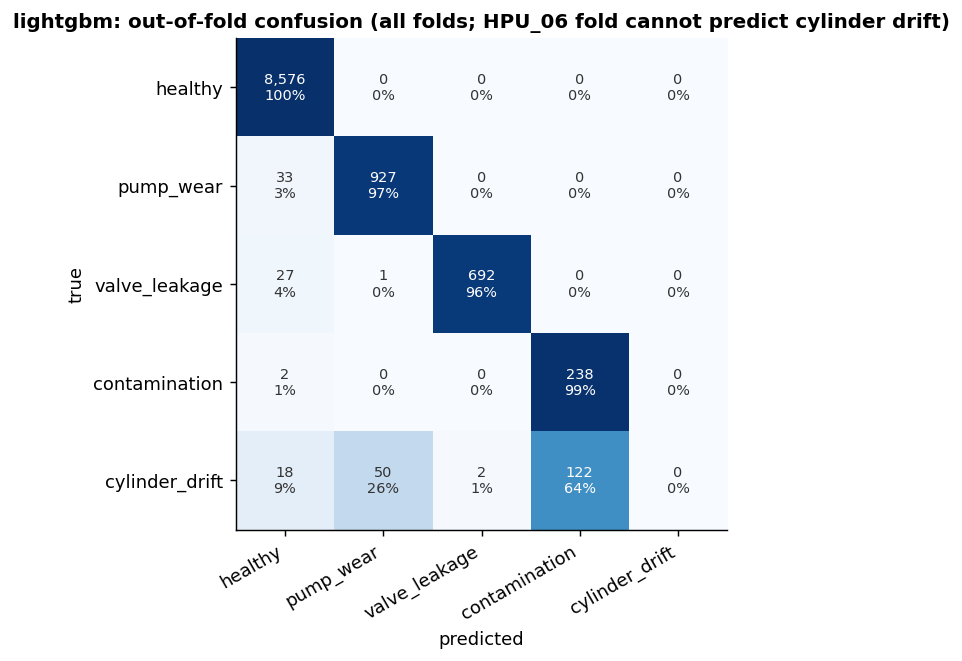

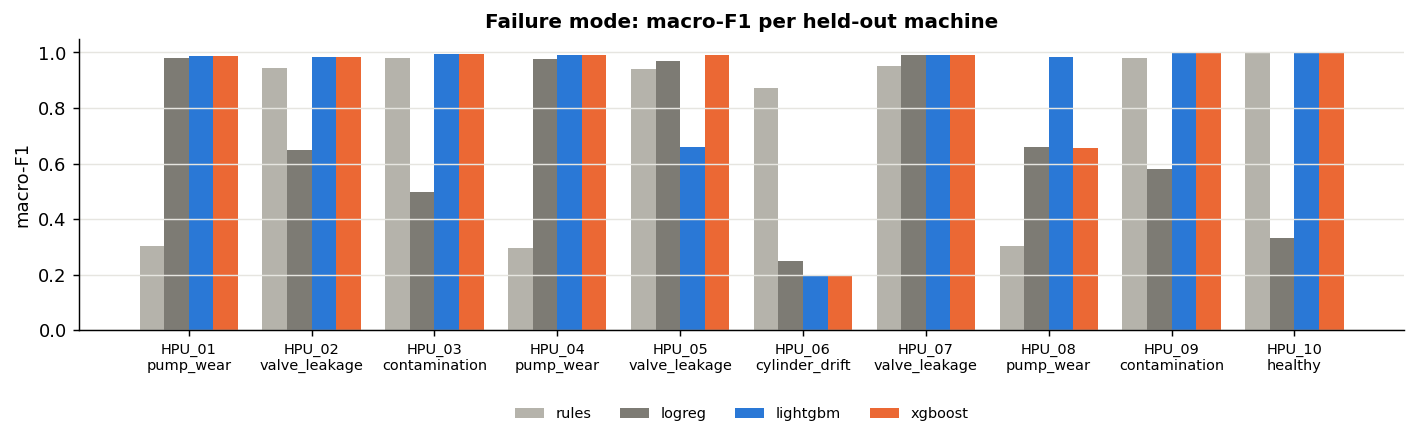

In [8]:
best = report["tasks"]["failure_mode"]["gate"]["selected"]
show(f"failure_mode_{best}_confusion", 560)
show("failure_mode_per_fold")

In [9]:
ev = pd.DataFrame(report["tasks"]["failure_mode"]["events"][best])
ev.round(2)

,event_id,machine_id,true_mode,predicted_mode,share_hours_flagged,share_flagged_as_true_mode,correct
0,F_009,HPU_09,contamination,contamination,1.00,1.0,True
1,F_005,HPU_05,valve_leakage,valve_leakage,0.96,1.0,True
2,F_003,HPU_03,contamination,contamination,0.98,1.0,True
3,F_008,HPU_08,pump_wear,pump_wear,0.96,1.0,True
4,F_001,HPU_01,pump_wear,pump_wear,0.96,1.0,True
5,F_006,HPU_06,cylinder_drift,contamination,0.91,0.0,False
6,F_002,HPU_02,valve_leakage,valve_leakage,0.95,1.0,True
7,F_007,HPU_07,valve_leakage,valve_leakage,0.98,1.0,True
8,F_004,HPU_04,pump_wear,pump_wear,0.98,1.0,True


**Findings: failure mode**

- **LightGBM reaches a pooled macro-F1 of 0.988** on the nine folds whose mode was seen in training (XGBoost 0.988, logistic regression 0.944, rules 0.623). It beats both baselines, so it is registered as `hpu-failure-mode@champion`.
- **Not one of the 8,576 healthy hours was flagged**, on any held-out machine. 97 % of pump-wear, 96 % of valve-leakage and 99 % of contamination hours are named correctly. **Every missed degradation hour lies in the first 14 hours of its window**, before the signal has built up. Pump wear is never called valve leakage; one valve-leakage hour was called pump wear.
- **8 of 9 events are identified by mode.** The miss is HPU_06, which cannot be named in its own fold. The model still flags **91 %** of its degradation hours as abnormal, mostly as contamination (64 %), which is the other mode with X−Y vibration divergence. In operation that means "abnormal, inspect" rather than silence.
- The rule baseline names only 6 of 9 events. On HPU_01 and HPU_08 the vibration rule fires first, so it calls pump wear "contamination". Fixed rules cannot weigh several signals at once; the model can.
- Per-fold macro-F1 is fragile. On HPU_05 a *single* hour predicted as pump wear adds a class with F1 = 0 to that fold's average (0.66). The pooled figures are the reliable read.

**Reading the results.** The confusion matrix is row-normalised (each true class sums to 100 %). The two errors that matter most are *degradation predicted as healthy* (a missed failure, the left column) and *healthy predicted as a failure mode* (a false alarm, the top row). Mixing up two failure modes is less costly: the machine still gets inspected, and SHAP (§10) shows the engineer which signals drove the call.

The HPU_06 row can only ever be *detected* in its own fold, never named, because no other machine has cylinder drift. That limitation is structural (one event), not a modelling choice, and more cylinder-drift events from the CMMS are the only fix.

## 7. RUL regression

Censored rows (no failure observed within 14 days of the end of data) are excluded from training and scoring. Predictions are clipped to [0, 336 h].

In [10]:
table("rul", ["mae_critical", "rmse_critical", "nasa_critical", "mae_all", "rmse_all", "nasa_all", "n_critical"]).round(3)

,mae_critical,rmse_critical,nasa_critical,mae_all,rmse_all,nasa_all,n_critical
constant,120.912,146.448,0.752,83.968,101.512,0.415,2928.0
ridge,45.606,68.404,0.234,25.601,43.725,0.115,2928.0
lightgbm,41.246,67.548,0.216,22.988,44.089,0.106,2928.0
xgboost,39.886,64.938,0.206,23.994,45.292,0.108,2928.0


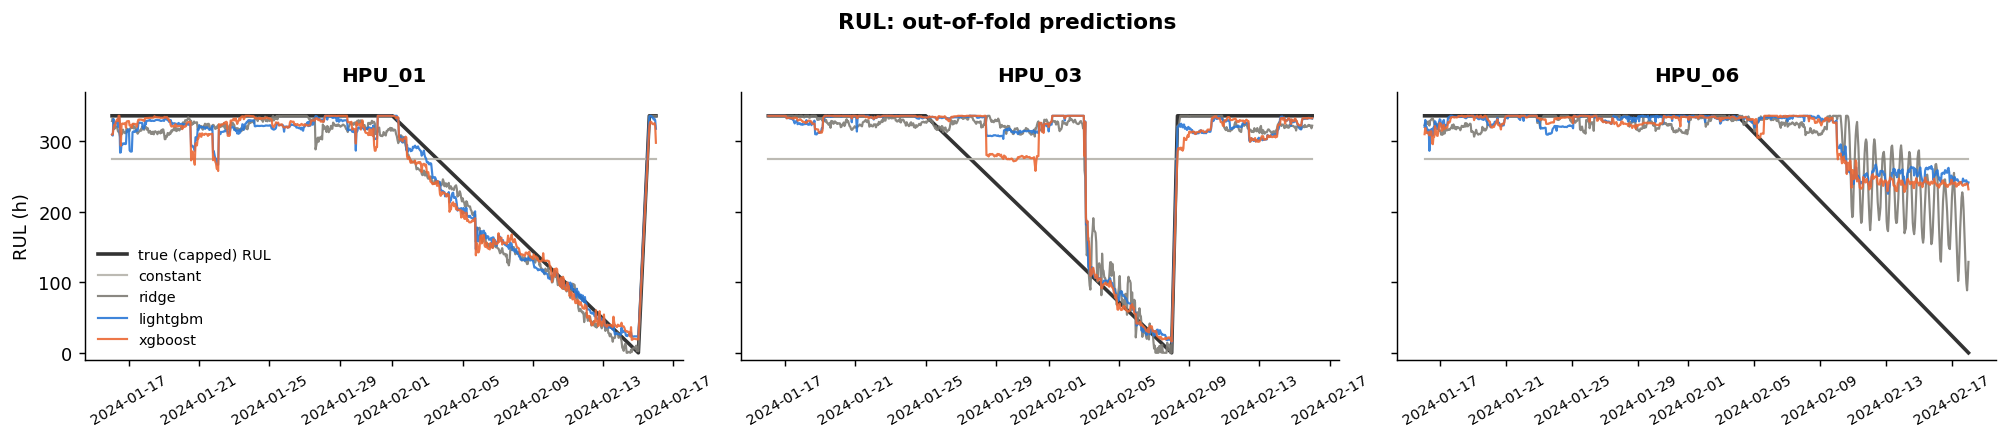

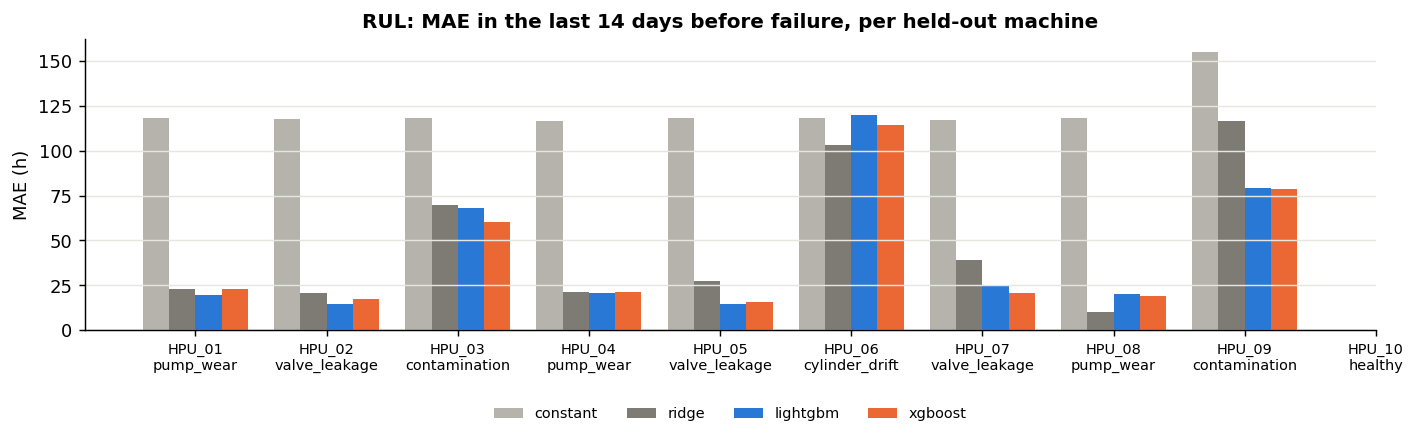

In [11]:
show("rul_traces", 1000)
show("rul_per_fold")

**Findings: RUL**

- **XGBoost has an MAE of 39.9 h over the last 14 days before failure** (LightGBM 41.2, ridge 45.6, constant 120.9) and the lowest NASA score (0.206). It is registered as `hpu-rul@champion`.
- **Accuracy depends strongly on the mode.** In the last 14 days the MAE per held-out machine is 19–23 h for pump wear and 16–21 h for valve leakage, but 61–79 h for contamination and 114 h for cylinder drift.
- **Contamination is limited by physics, not by the model.** Its RUL target counts down from 14 days, but the sensor signal only appears about 5 days before failure. Until then no model can know the clock is running (HPU_03 trace). Once the signal appears, the prediction follows the true RUL closely.
- **Cylinder drift (unseen mode) is the risk.** On HPU_06 the prediction flattens at about 240 h while the true RUL runs to zero, so the model *promises too much life*. That is the costly error. **Recommendation for Stage 6:** show a RUL only when the classifier names a known mode with high confidence; otherwise show "abnormal, inspect", not an hour count.

**Reading the results.** The constant model shows how much a model must learn to be useful at all. The traces show the typical shape of a capped-RUL model: flat at the cap while the machine is healthy, then a descent once degradation becomes visible. The descent starts only when the degradation *signal* starts, which for fast modes (contamination, 5-day windows) is late, so the error in the last 14 days is dominated by the first days of each window.

## 8. Early warning

Operating-point metrics (thresholds chosen per fold on the training machines). *Recall* is hourly over the hours with a failure within 7 days; *precision* counts an alarm-hour as correct if a failure follows within 7 days or the machine is in a labelled degradation window; the *false-alarm rate* is the share of healthy hours in alarm; *lead time* is per failure event, from the first alarm inside the event's warning window (the earlier of the degradation start and failure − 7 d) to the failure. Alarms before that window count as false alarms.

In [12]:
table("early_warning", ["lead_time_mean_h", "lead_time_median_h", "events_detected", "events_total", "false_alarm_rate",
                        "false_alarm_episodes_per_1000h", "precision", "recall", "pr_auc", "roc_auc", "brier"]).round(4)

,lead_time_mean_h,lead_time_median_h,events_detected,events_total,false_alarm_rate,false_alarm_episodes_per_1000h,precision,recall,pr_auc,roc_auc,brier
rules,195.3333,201.0,9.0,9.0,0.0000,0.0000,1.0000,0.8955,NaN,NaN,NaN
logreg,205.6667,214.0,9.0,9.0,0.0101,0.8574,0.9605,0.8626,0.9013,0.9026,0.0249
lightgbm,220.8889,219.0,9.0,9.0,0.0000,0.0000,1.0000,0.9310,0.9452,0.9518,0.0174
xgboost,217.1111,221.0,9.0,9.0,0.0043,0.4287,0.9841,0.8475,0.8902,0.9330,0.0333
lightgbm@rules_far,219.7778,219.0,9.0,9.0,0.0000,0.0000,1.0000,0.9034,0.9452,0.9518,0.0174
xgboost@rules_far,213.6667,212.0,9.0,9.0,0.0026,0.2858,0.9900,0.8330,0.8902,0.9330,0.0333


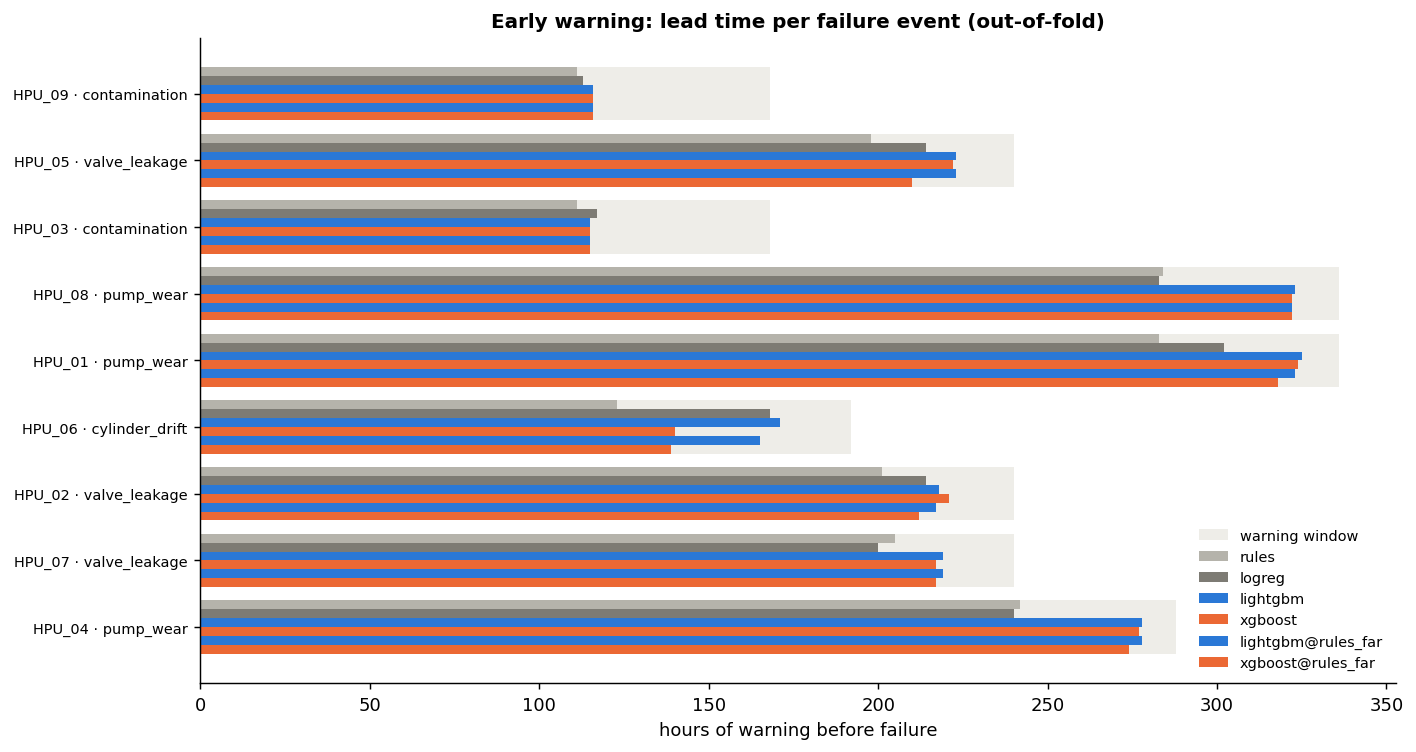

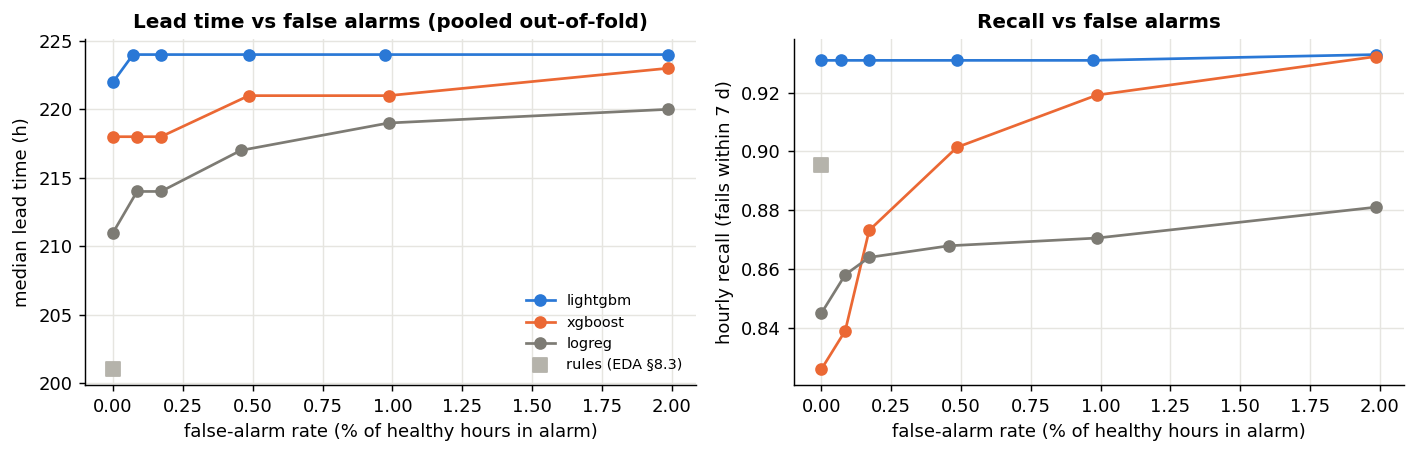

In [13]:
show("early_warning_lead_times", 1000)
show("early_warning_far_curve", 1000)

In [14]:
ew_best = report["tasks"]["early_warning"]["gate"]["selected"]
pd.DataFrame(report["tasks"]["early_warning"]["per_fold"][ew_best]).round(4)

,fold,test_machine,threshold_raw,threshold_prob,inner_far,far,recall,precision,lead_time_h
0,0,HPU_01,0.0149,0.0159,0.0019,0.0,1.0000,1.0,325.0
1,1,HPU_02,0.1800,0.5000,0.0019,0.0,1.0000,1.0,218.0
2,2,HPU_03,0.0065,0.0684,0.0019,0.0,0.6864,1.0,115.0
3,3,HPU_04,0.0140,0.0270,0.0018,0.0,1.0000,1.0,278.0
4,4,HPU_05,0.0335,0.0909,0.0019,0.0,1.0000,1.0,223.0
5,5,HPU_06,0.0184,0.0163,0.0019,0.0,1.0000,1.0,171.0
6,6,HPU_07,0.0155,0.0182,0.0019,0.0,1.0000,1.0,219.0
7,7,HPU_08,0.0491,0.3750,0.0019,0.0,1.0000,1.0,323.0
8,8,HPU_09,0.0082,0.0790,0.0018,0.0,0.6923,1.0,116.0
9,9,HPU_10,0.0145,0.0345,0.0018,0.0,0.0000,0.0,NaN


**Findings: early warning**

- **A correction made during this stage.** The first real-data run counted alarms in the early part of long degradation windows (pump wear 14 d, valve leakage 10 d, where the 7-day target is still 0) as false alarms. That gave the rules a 5.3 % false-alarm rate. All 405 of those alarm-hours were in fact inside labelled degradation windows; **on healthy hours the rules raise no alarms at all**, as the EDA found. The definition was corrected (a false alarm is an alarm on a healthy hour), those hours were removed from model fitting and calibration, and a test now guards the definition.
- **At zero false alarms, LightGBM warns of all 9 failures, with a mean lead time of 221 h (9.2 days) against 195 h (8.1 days) for the rules.** Because the rules raised no false alarms, the models were also re-run with a zero-false-alarm target (`lightgbm@rules_far`: 220 h, 9/9, still zero false alarms). The comparison is like for like. Every held-out machine ended with a realised false-alarm rate of 0.
- **Median lead time by mode, LightGBM vs rules:** pump wear 323 h vs 283 h, valve leakage 219 h vs 201 h, **cylinder drift 171 h vs 123 h**, contamination 116 h vs 111 h. Hourly recall is 0.93 vs 0.90. PR-AUC is 0.945 and Brier 0.017, so the probabilities are well calibrated.
- **Warnings arrive close to the start of each labelled window.** For pump wear the first alarm comes about 13 h after the labelled degradation start (323 of 336 h). Much more lead time would need an earlier physical signal than the labels contain.
- **Caveats.** (1) The rule thresholds were set in the EDA by inspecting all ten machines, so the rules are evaluated *in-sample* and are, if anything, flattered; the models were not. (2) With 9 events, one event moves the mean lead time by 10–30 h, so the 26 h margin is real but modest; the clearer gains are on cylinder drift and recall. (3) The calibrated threshold varies between folds (per-fold table), yet no fold raised a false alarm on its held-out machine. Stage 7 should monitor the alarm rate per machine.

**Reading the results.** The per-fold table shows the threshold each fold chose on its own training machines and the false-alarm rate it achieved there (`inner_far`) versus on the held-out machine (`far`). A held-out rate well above the inner one would mean the threshold does not transfer between machines, which is the main deployment risk for any fleet-wide alarm.

The trade-off curve is **descriptive**: it sets one threshold on the pooled out-of-fold scores, so it is slightly optimistic compared with the per-fold operating point in the table above. The square marks the EDA rule detector, which has a single operating point.

One structural limit applies to every model here: contamination has a 5-day degradation window inside a 7-day target, so the first 2 days of each positive window carry no signal.

## 9. Sequence model: decision

The Stage 2 plan listed a 1D-CNN / LSTM on the hourly sequence as optional, to be kept only if it clearly beats gradient boosting. It was **not built** in this stage:

* **Too few sequences to learn from.** A sequence model learns the shape of degradation trajectories. There are 9 trajectories in total, and 8 in any training fold. Boosting on engineered features needs far fewer examples because the temporal shape is already encoded in the 6/24/72 h rolling means, slopes, lags and spectral features.
* **The evaluation could not show a *clear* win.** With 9 events, the LOMO lead-time and F1 estimates move by a whole event at a time; a difference between two strong models would be inside that noise.
* **Cost.** A deep-learning stack (PyTorch) would add a heavy dependency to the Stage 5 container for no demonstrated gain.

Revisit when the 2024 CMMS export adds failure events (the same request as for cylinder drift).

## 10. Explainability (SHAP)

SHAP values are computed on the final models (trained on all machines). For the classifier they are shown per failure mode; units are log-odds. The calibrator of the early-warning model is monotone, so features that raise the log-odds also raise the calibrated probability.

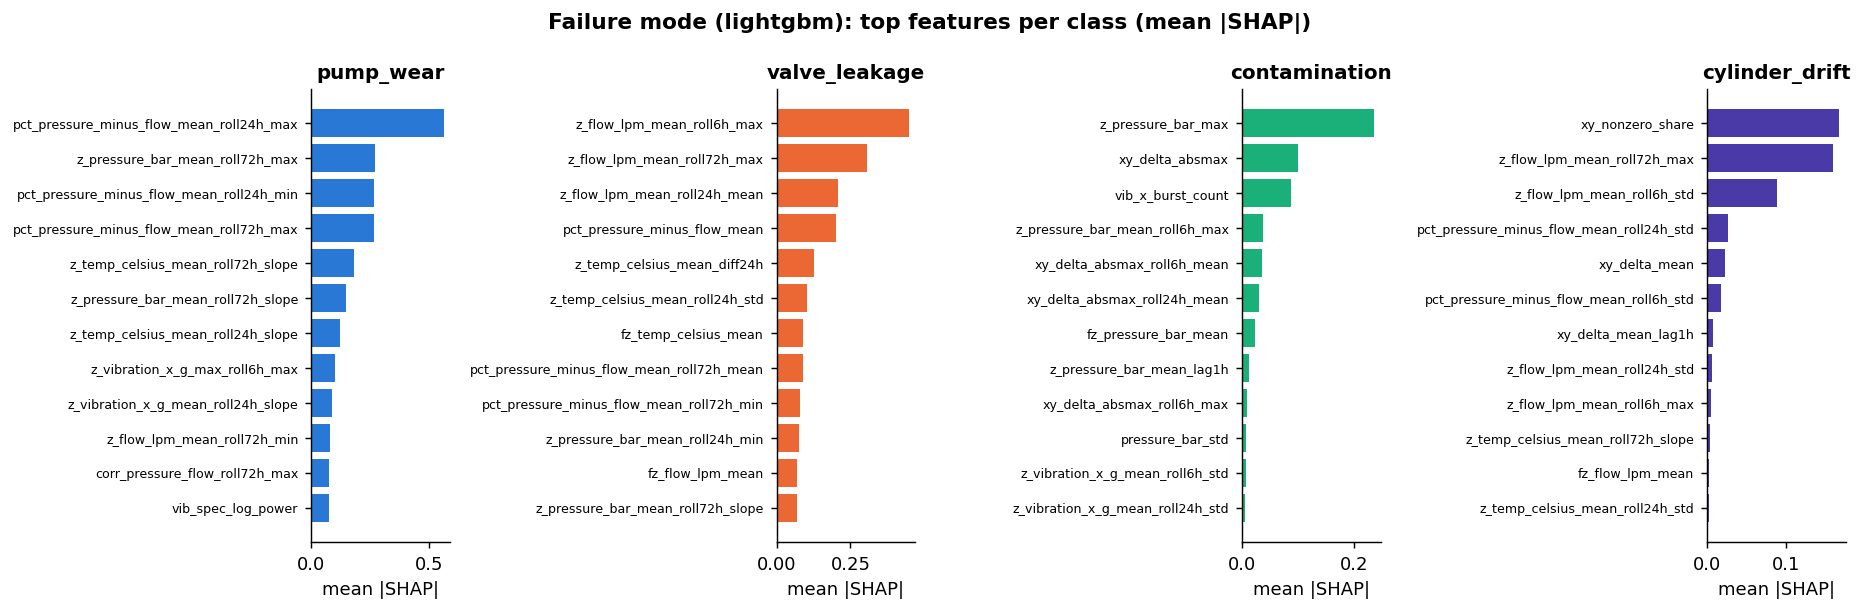

,contamination,cylinder_drift,healthy,pump_wear,valve_leakage,total
feature,,,,,,
z_pressure_bar_mean_roll24h_std,0.0000,0.0000,1.0203,0.0364,0.0072,1.0639
pct_pressure_minus_flow_mean_roll24h_max,0.0000,0.0000,0.0091,0.5620,0.0008,0.5719
z_flow_lpm_mean_roll72h_max,0.0000,0.1598,0.0529,0.0293,0.3061,0.5481
z_flow_lpm_mean_roll6h_max,0.0000,0.0056,0.0035,0.0009,0.4475,0.4575
z_pressure_bar_max,0.2356,0.0004,0.1582,0.0331,0.0000,0.4273
pct_pressure_minus_flow_mean_roll72h_std,0.0000,0.0000,0.3598,0.0397,0.0025,0.4020
pct_pressure_minus_flow_mean_roll24h_std,0.0000,0.0267,0.3073,0.0247,0.0010,0.3597
pct_pressure_minus_flow_mean,0.0005,0.0007,0.0777,0.0624,0.2026,0.3440
pct_pressure_minus_flow_mean_roll24h_min,0.0000,0.0012,0.0141,0.2676,0.0345,0.3174


In [15]:
show("shap_failure_mode", 1100)
pd.read_csv("reports/stage3_shap_failure_mode.csv", index_col=0).head(15).round(4)

**Findings: global explanations.** Each mode is driven by the fingerprint the EDA found, which is good evidence that the model learned fault physics rather than machine identity:
- **Pump wear:** the pressure-minus-flow deviation (pressure falls faster than flow), plus 72 h pressure and temperature trends.
- **Valve leakage:** flow deviation (flow falls) and the 24 h temperature change.
- **Contamination:** pressure maxima (pressure *rises*), X−Y divergence and vibration bursts.
- **Cylinder drift:** the share of minutes where vibration X and Y differ, plus flow.

**Why did an alert fire?** The example below takes the event with the longest warning and explains the model's score at the hour of the first alarm. This is the view the Stage 6 dashboard will show next to each alert: the top contributing features, their current values, and the direction in which each pushed the score.

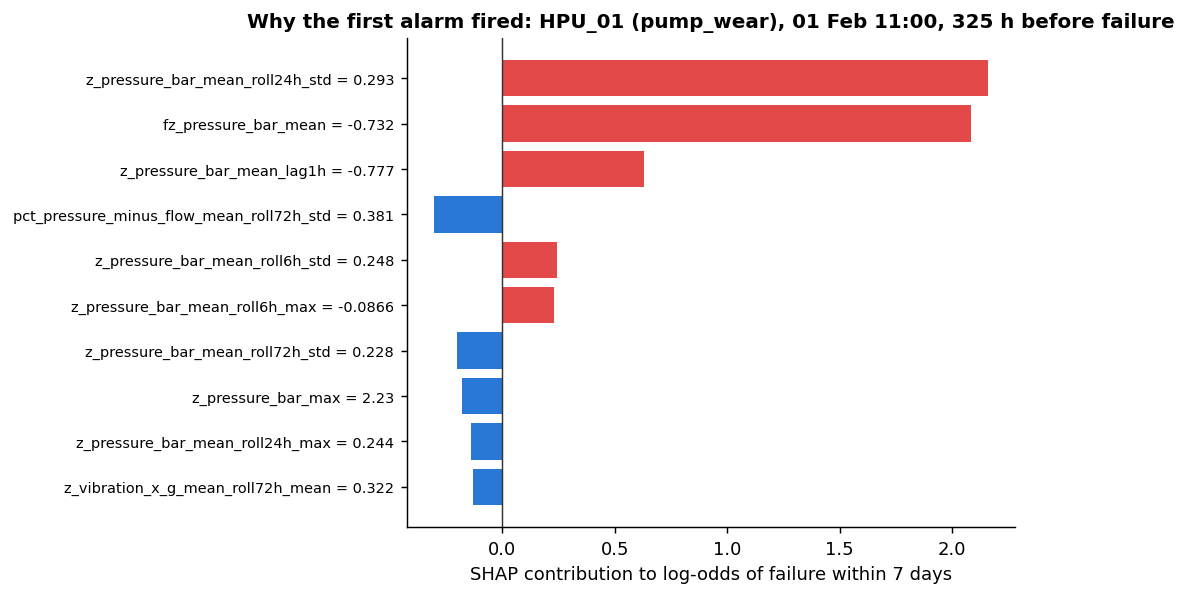

,rank,feature,value,shap,description
0,1,z_pressure_bar_mean_roll24h_std,0.2927,2.1570,trailing 24 h std of z_pressure_bar_mean
1,2,fz_pressure_bar_mean,-0.7322,2.0839,z_pressure_bar_mean minus the fleet median at ...
2,3,z_pressure_bar_mean_lag1h,-0.7770,0.6310,z_pressure_bar_mean 1 h earlier
3,4,pct_pressure_minus_flow_mean_roll72h_std,0.3812,-0.3014,trailing 72 h std of pct_pressure_minus_flow_mean
4,5,z_pressure_bar_mean_roll6h_std,0.2483,0.2426,trailing 6 h std of z_pressure_bar_mean
5,6,z_pressure_bar_mean_roll6h_max,-0.0866,0.2316,trailing 6 h max of z_pressure_bar_mean
6,7,z_pressure_bar_mean_roll72h_std,0.2283,-0.2019,trailing 72 h std of z_pressure_bar_mean
7,8,z_pressure_bar_max,2.2251,-0.1787,hourly max of pressure_bar z-score vs own same...
8,9,z_pressure_bar_mean_roll24h_max,0.2436,-0.1367,trailing 24 h max of z_pressure_bar_mean
9,10,z_vibration_x_g_mean_roll72h_mean,0.3219,-0.1321,trailing 72 h mean of z_vibration_x_g_mean


In [16]:
if (FIG_DIR / "stage3_shap_alert_example.png").exists():
    show("shap_alert_example", 800)
    display(pd.read_csv("reports/stage3_shap_alert_example.csv")[["rank", "feature", "value", "shap", "description"]].round(4))

**Finding: why the first alarm fired.** The earliest-warning event is HPU_01 (pump wear), alarmed at 11:00 on 1 Feb, about 11 h after the labelled degradation start and 325 h before the failure. The alarm is driven by **rising pressure variability over 24 h** and by **pressure falling below the fleet median at the same hour** (fleet-relative z ≈ −0.7). An engineer can check both on the raw trend.

## 11. Model Registry

Each task's selected model is logged as an `mlflow.pyfunc` model that bundles the estimator, the exact feature list and order, the class labels, and for early warning the calibrator, threshold and persistence rule. It is registered under `hpu-failure-mode`, `hpu-rul` and `hpu-early-warning`. The alias `@champion` is set only when the model passed the gate on real data; Stage 4 CI and the Stage 5 service load `models:/<name>@champion`.

In [17]:
client = mlflow.MlflowClient()
reg = []
for task, name in cfg["modelling"]["registry"]["names"].items():
    for v in client.search_model_versions(f"name='{name}'"):
        mv = client.get_model_version(name, v.version)          # search results do not carry aliases
        reg.append({"name": name, "version": int(mv.version), "aliases": ", ".join(mv.aliases), **mv.tags})
pd.DataFrame(reg).sort_values(["name", "version"])

,name,version,aliases,primary_metric,value,passes_gate,data_label,dataset_hash
2,hpu-early-warning,1,champion,lead_time_mean_h,220.8889,True,real,0f087751a4eb
0,hpu-failure-mode,1,champion,macro_f1_seen,0.9885,True,real,0f087751a4eb
1,hpu-rul,1,champion,mae_critical,39.8865,True,real,0f087751a4eb


In [18]:
# Load the registered model exactly as the Stage 5 service will, and score the latest hours of one machine
name = cfg["modelling"]["registry"]["names"]["early_warning"]
entry = report["tasks"]["early_warning"]["registered"]
uri = f"models:/{name}@{entry['alias']}" if entry.get("alias") else f"models:/{name}/{entry['version']}"
model = mlflow.pyfunc.load_model(uri)
latest = ds[ds.machine_id == data.events.iloc[0].machine_id].tail(6)
model.predict(latest[data.features]).assign(timestamp=latest.timestamp.values).round(3)

,p_fail_within_horizon,raw_score,above_threshold,timestamp
12954,0.015,0.001,False,2024-02-29 19:00:00
12955,0.015,0.001,False,2024-02-29 20:00:00
12956,0.015,0.001,False,2024-02-29 21:00:00
12957,0.015,0.000,False,2024-02-29 22:00:00
12958,0.015,0.000,False,2024-02-29 23:00:00
12959,0.015,0.000,False,2024-03-01 00:00:00


## 12. Summary and plan for Stage 4

The table below is generated from the run above (`reports/stage3_model_comparison.md`, also logged to MLflow).

### Key results (leave-one-machine-out, real data)
| Task | Selected model | Headline | Best baseline | Registered |
|---|---|---|---|---|
| Failure mode | LightGBM | macro-F1 **0.988** (seen folds); 0 of 8,576 healthy hours flagged; 8/9 events named; HPU_06 91 % detected | logistic regression 0.944 | `hpu-failure-mode@champion` |
| RUL | XGBoost | MAE **39.9 h** in the last 14 days (pump / valve 16–23 h, contamination 61–79 h) | ridge 45.6 h | `hpu-rul@champion` |
| Early warning | LightGBM | **9/9** failures, mean lead **221 h** (9.2 d), **0 false alarms** | rules 195 h (8.1 d), 0 false alarms | `hpu-early-warning@champion` |

**Main limitations:** only 9 failure events, so every estimate carries event-level uncertainty. Cylinder drift occurs once, so it cannot be named, and its RUL is over-estimated (show "inspect" instead). Contamination warns about 5 days ahead because that is when its signal appears.

In [19]:
display(Markdown(Path("reports/stage3_model_comparison.md").read_text()))

# Stage 3 model comparison (real data)

Leave-one-machine-out, out-of-fold. Dataset `0f087751a4eb`, 171 features. MLflow parent run `3bf75f1ca15f42d48d9d240383965748`.

## Failure-mode classification

| model | macro-F1 (seen folds) | macro-F1 (all folds) | detection recall | healthy FPR | HPU_06 detection | events correct |
|---|---:|---:|---:|---:|---:|---:|
| rules | 0.623 | 0.655 | 0.837 | 0.000 | 0.646 | 6/9 |
| logreg | 0.944 | 0.734 | 0.958 | 0.004 | 0.995 | 8/9 |
| **lightgbm** | 0.988 | 0.745 | 0.962 | 0.000 | 0.906 | 8/9 |
| xgboost | 0.988 | 0.767 | 0.964 | 0.000 | 0.917 | 8/9 |

Selected **lightgbm** on `macro_f1_seen` = 0.988; beats baselines: {'rules': True, 'logreg': True}; gate passed: **True**. Registered as `hpu-failure-mode` v1 with alias `@champion`.

## RUL regression

| model | MAE last 14 d (h) | RMSE last 14 d (h) | NASA last 14 d | MAE all (h) | RMSE all (h) |
|---|---:|---:|---:|---:|---:|
| constant | 120.9 | 146.4 | 0.752 | 84.0 | 101.5 |
| ridge | 45.6 | 68.4 | 0.234 | 25.6 | 43.7 |
| lightgbm | 41.2 | 67.5 | 0.216 | 23.0 | 44.1 |
| **xgboost** | 39.9 | 64.9 | 0.206 | 24.0 | 45.3 |

Selected **xgboost** on `mae_critical` = 39.886; beats baselines: {'constant': True, 'ridge': True}; gate passed: **True**. Registered as `hpu-rul` v1 with alias `@champion`.

## Early warning (7 days)

| model | mean lead (h) | median lead (h) | events detected | false-alarm rate | precision | recall | PR-AUC | Brier |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| rules | 195.3 | 201.0 | 9/9 | 0.0000 | 1.000 | 0.895 | – | – |
| logreg | 205.7 | 214.0 | 9/9 | 0.0101 | 0.960 | 0.863 | 0.901 | 0.025 |
| **lightgbm** | 220.9 | 219.0 | 9/9 | 0.0000 | 1.000 | 0.931 | 0.945 | 0.017 |
| xgboost | 217.1 | 221.0 | 9/9 | 0.0043 | 0.984 | 0.847 | 0.890 | 0.033 |
| lightgbm@rules_far | 219.8 | 219.0 | 9/9 | 0.0000 | 1.000 | 0.903 | 0.945 | 0.017 |
| xgboost@rules_far | 213.7 | 212.0 | 9/9 | 0.0026 | 0.990 | 0.833 | 0.890 | 0.033 |

Selected **lightgbm** on `lead_time_mean_h` = 220.889; beats baselines: {'rules': True, 'logreg': True}; gate passed: **True**. Registered as `hpu-early-warning` v1 with alias `@champion`.


### What Stage 3 delivers
- A **tested modelling package** (`src/pdm/models`, 16 new tests, 43 in total) and a CLI, `python -m pdm.train`.
- **Baselines and models for all three tasks**, evaluated leave-one-machine-out with the unseen cylinder-drift fold reported separately.
- A **leakage-free early-warning protocol**: calibration and alarm threshold chosen on the training machines of each fold, lead time reported at a fixed false-alarm rate.
- **MLflow tracking** of every run (git commit, config hash, dataset fingerprint, per-fold metrics, predictions, figures) and a **Model Registry** with a gated `@champion` alias.
- **SHAP explanations**, globally per failure mode and per alert.
- A **synthetic data generator** (`python -m pdm.synthetic`) with the real schema and EDA characteristics, so CI can run the whole pipeline without the private data. Its metrics are never reported.

### Open points for the client
| Topic | Why it matters | Request |
|---|---|---|
| More failure events (CMMS 2024) | 9 events limit every estimate; cylinder drift has 1 | export of all 2023–2024 failures with timestamps and modes |
| False-alarm budget | the operating point (0.2 % of healthy hours) is our assumption | the site's tolerated false alarms per machine per month |
| Cost of a late vs early prediction | sets the NASA-score constants and the alarm threshold | production-loss rate per downtime hour |

### Proposed Stage 4: CI/CD with GitHub Actions (for your confirmation)
1. **CI on every pull request:** lint, the 43 unit tests, and an end-to-end smoke run (`pdm.synthetic` → `pdm.pipeline` → `pdm.train --data-label synthetic --no-register`) on the synthetic data, in a few minutes.
2. **Data-validation job:** the Stage 2 validation gate on each new data batch, publishing the validation report as a build artifact.
3. **Training workflow (manual / scheduled):** run on real data with access to the data store and the MLflow server, and fail if the new model does not pass the gate against the current `@champion`.
4. **Model promotion:** move the `@champion` alias only through a reviewed workflow, recording the git commit and dataset fingerprint.
5. **Remote MLflow tracking server** (replacing the local SQLite store) so runs from CI, Colab and laptops land in one place.